In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib.patches import Rectangle

In [3]:
# read file into df
X_train = pd.read_parquet('X_train.parquet', engine='fastparquet')
Y_train = pd.read_parquet('Y_train.parquet', engine= 'fastparquet')
df = pd.concat([X_train, Y_train], axis=1)
df.head()

,max_education_9-11th grade (includes 12th grade with no diploma),max_education_College graduate or above,max_education_High school graduate/GED or equivalent,max_education_Missing,max_education_Some college or AA degree,max_education_less than 9th grade,max_education_nan,marital_status_Divorced,marital_status_Living with partner,marital_status_Married,...,days_nicotine_replacement,days_hookah,days_ecigarette,hours_slept_weekday,hours_slept_weekend,recent_alcohol_use,dpq_total,depression_category,depression_binary,depression_severity
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.055462,-0.052624,-0.125735,0.260667,-0.753308,-0.079197,0.0,Minimal or no depression,False,0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,-0.055462,-0.052624,-0.125735,0.260667,-0.176540,-0.079197,0.0,Minimal or no depression,False,0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.055462,-0.052624,-0.125735,0.869289,0.111844,-0.079197,5.0,Mild depression,False,1
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.055462,-0.052624,-0.125735,-1.565201,-1.041692,15.849691,1.0,Minimal or no depression,False,0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.055462,-0.052624,-0.125735,-0.956579,0.400227,-0.038196,0.0,Minimal or no depression,False,0


In [4]:
# print shape and info
print(df.columns)

Index(['max_education_9-11th grade (includes 12th grade with no diploma)',
       'max_education_College graduate or above',
       'max_education_High school graduate/GED or equivalent',
       'max_education_Missing', 'max_education_Some college or AA degree',
       'max_education_less than 9th grade', 'max_education_nan',
       'marital_status_Divorced', 'marital_status_Living with partner',
       'marital_status_Married',
       ...
       'days_nicotine_replacement', 'days_hookah', 'days_ecigarette',
       'hours_slept_weekday', 'hours_slept_weekend', 'recent_alcohol_use',
       'dpq_total', 'depression_category', 'depression_binary',
       'depression_severity'],
      dtype='object', length=150)


In [5]:
df.dtypes.value_counts()

float64    147
object       1
bool         1
int64        1
Name: count, dtype: int64

In [6]:
# print top 5 rows of each column
print(df.depression_category.value_counts())

depression_category
Minimal or no depression        2257
Mild depression                  511
Moderate depression              170
Moderately severe depression      74
Severe depression                 28
Name: count, dtype: int64


In [7]:
depression_map = {
    'Minimal or no depression':0,
    'Mild depression':1,
    'Moderate depression':2,
    'Moderately severe depression':2,
    'Severe depression':2
}
df["dep_score"] = df['depression_category'].map(depression_map)
print(df["dep_score"].value_counts())

dep_score
0    2257
1     511
2     272
Name: count, dtype: int64


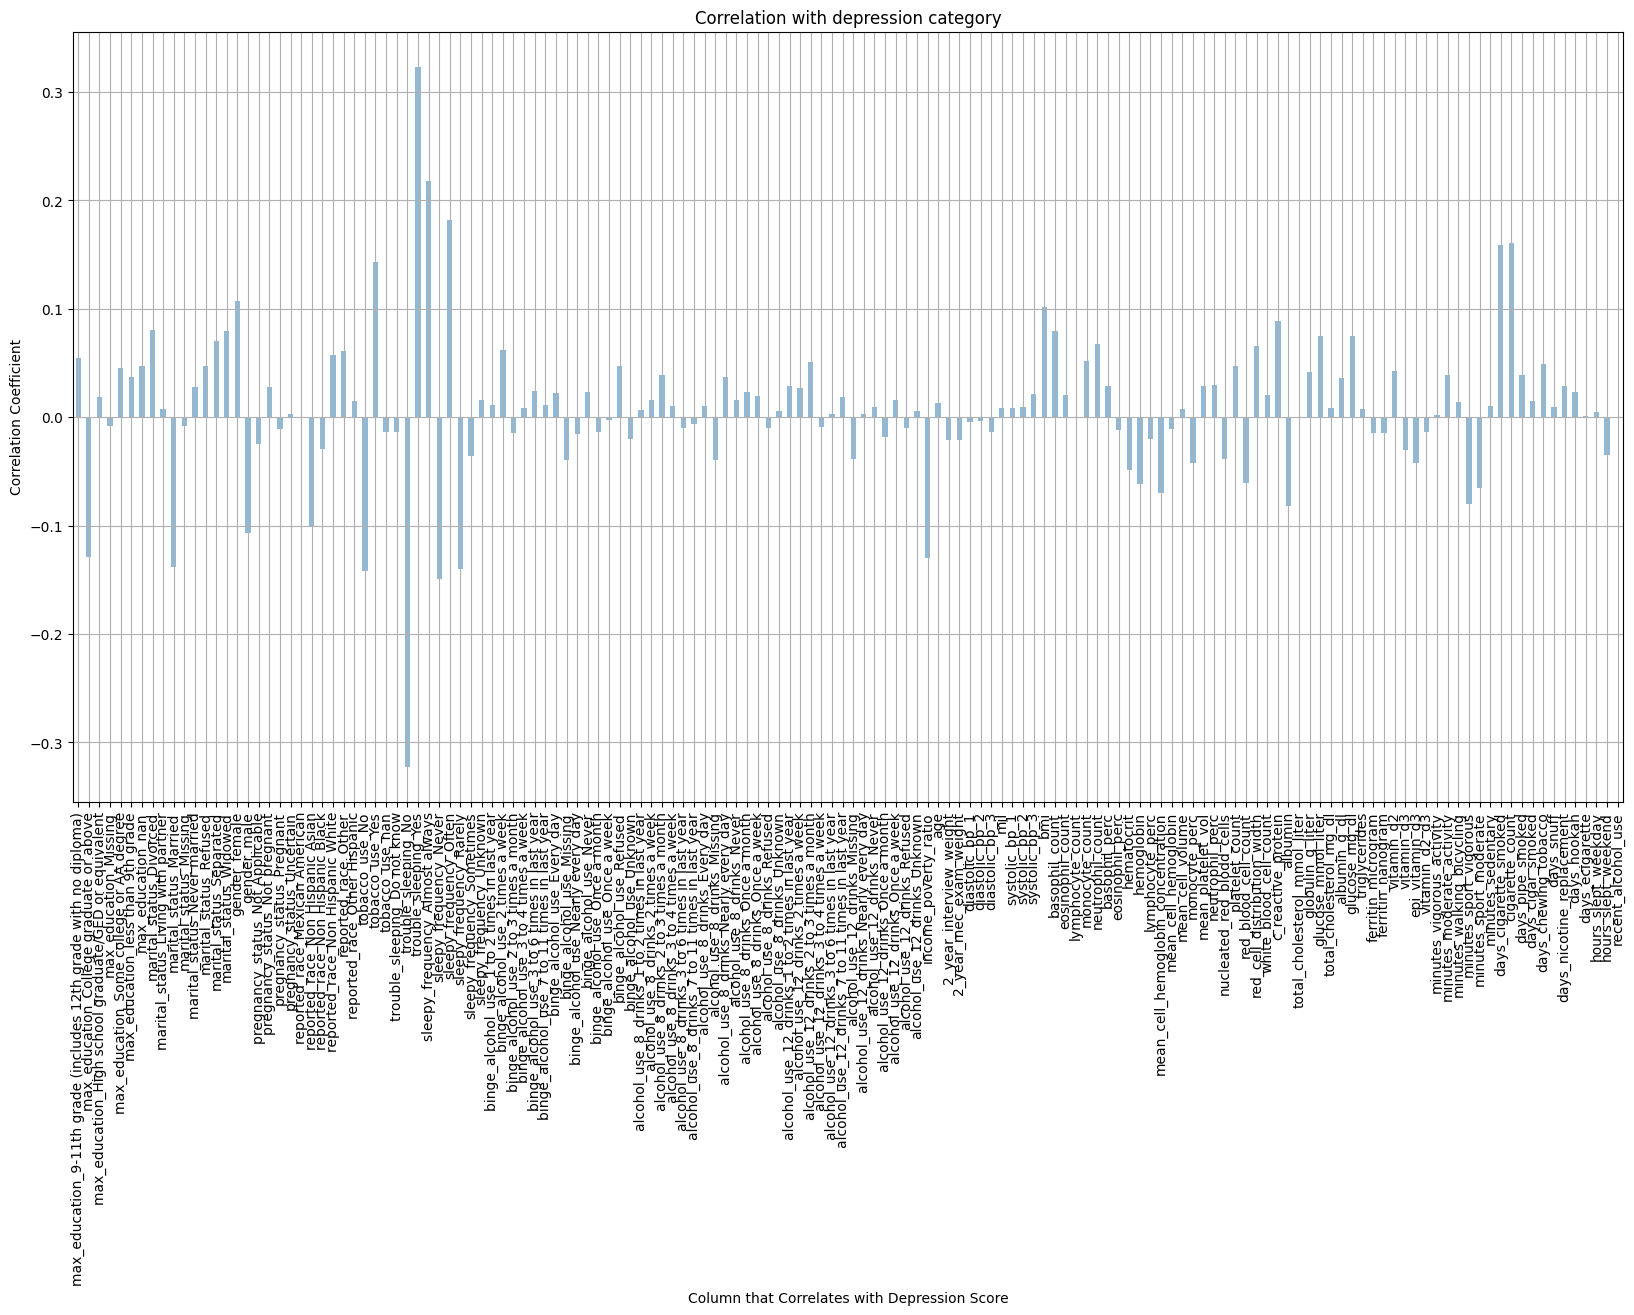

In [14]:
#drop dpq columns
cat_filter = ['dpq', 'depression_severity']
cat_filter_join = '|'.join(cat_filter)
df_train = df.loc[:, ~df.columns.str.contains(cat_filter_join)]

#Select numeric columns to allow for correlation calculation and graphing
numeric_df = df_train.select_dtypes(include=['float64', 'int64'])
correlations = numeric_df.corrwith(numeric_df.dep_score)
correlations.iloc[:-1].plot(kind='bar', title=f'Correlation with depression category', figsize=(20,10), grid = True, alpha = 0.5)
plt.xlabel('Column that Correlates with Depression Score')
plt.ylabel('Correlation Coefficient')
plt.show()

Text(0.5, 0, 'Depression Score')

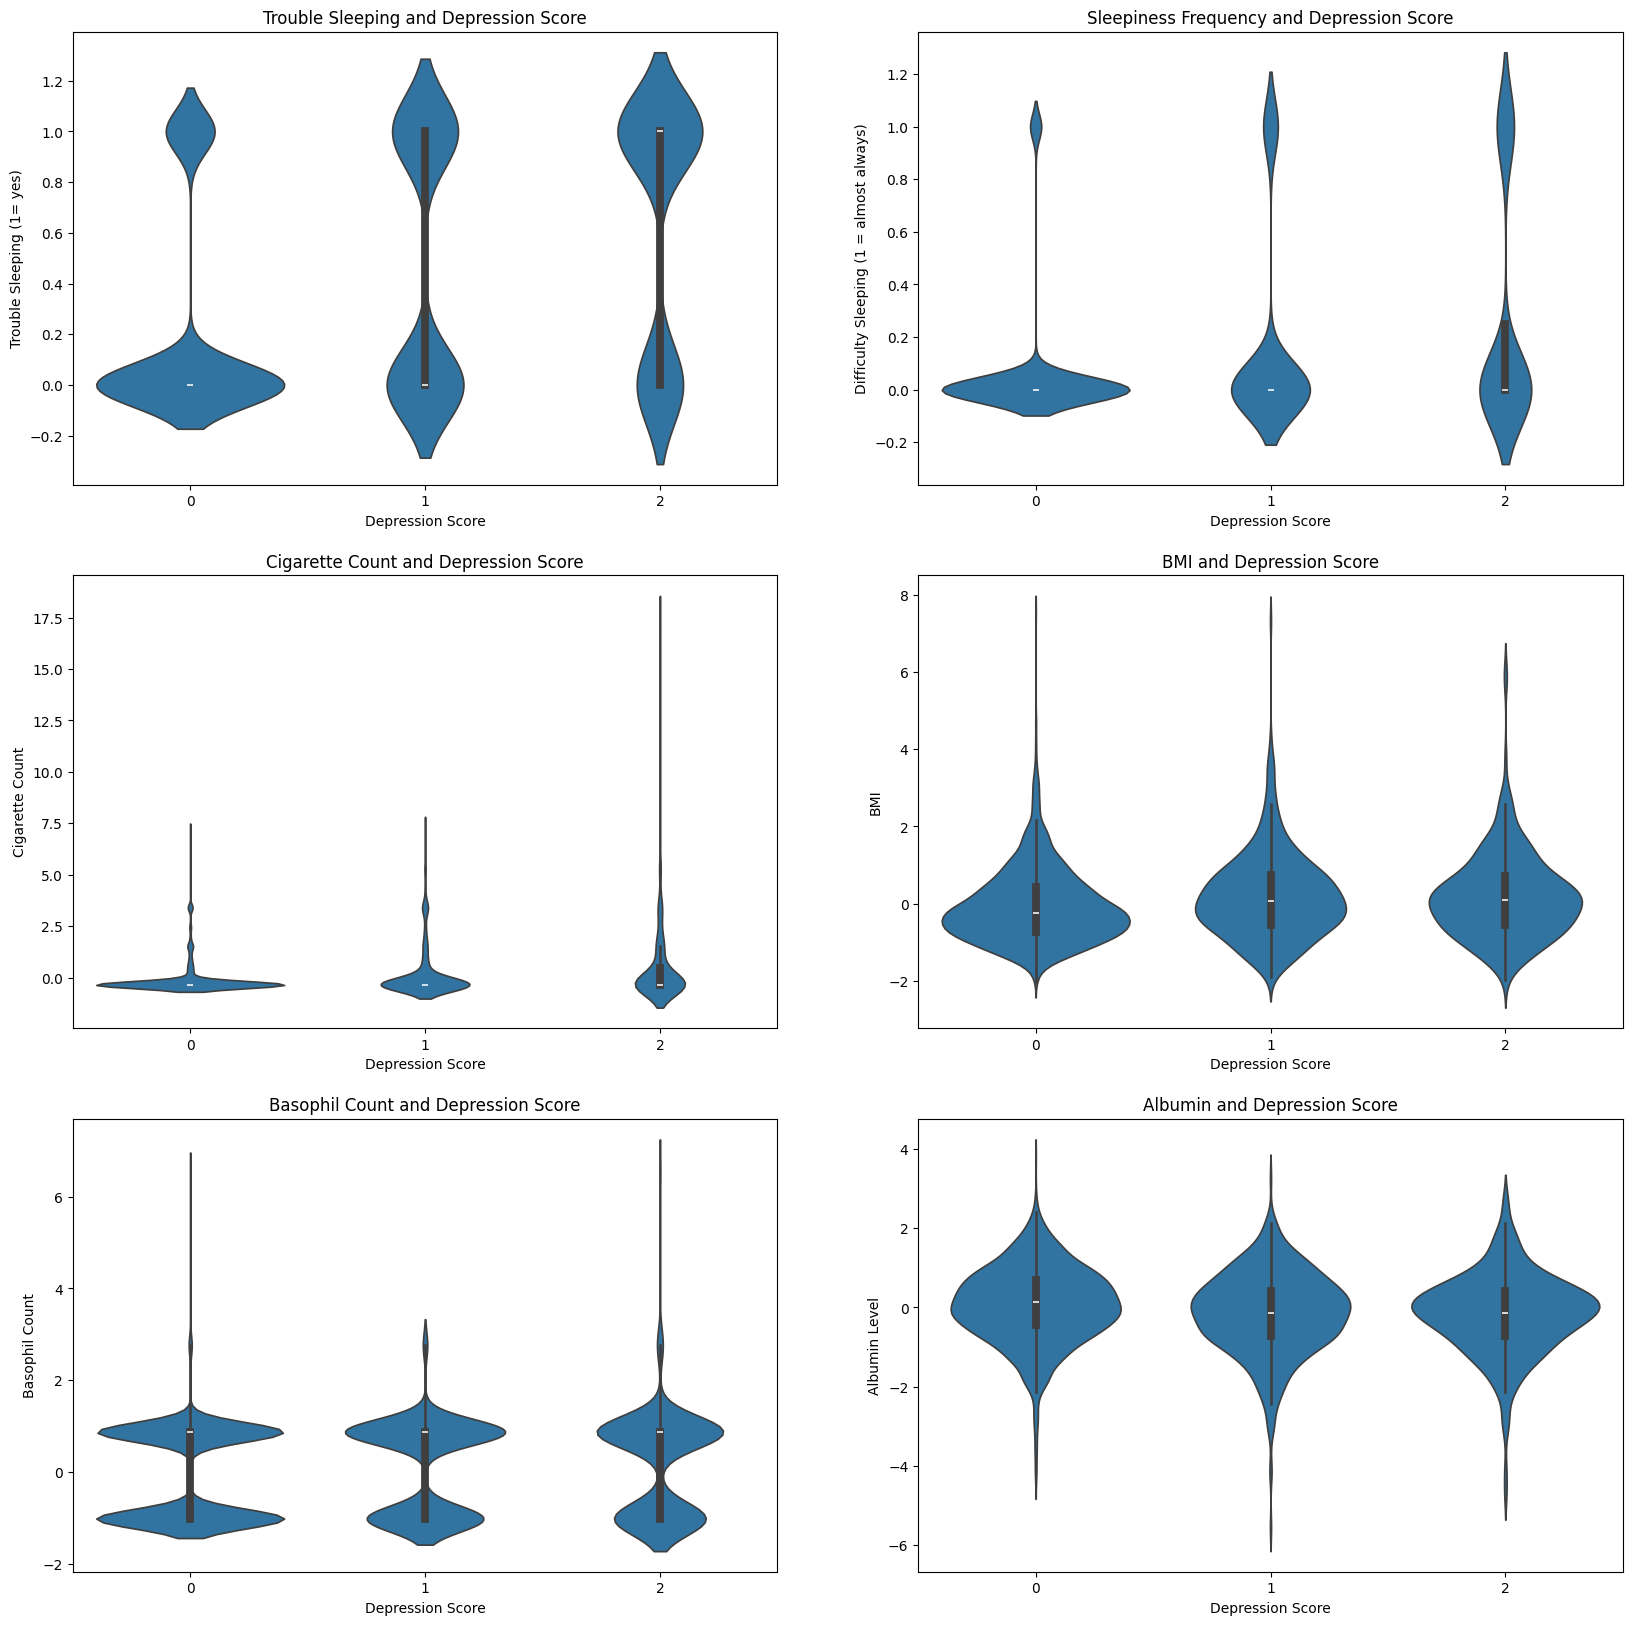

In [22]:
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
sns.violinplot(ax = axes[0,0], data = numeric_df, x='dep_score', y='trouble_sleeping_Yes')
axes[0,0].set_title('Trouble Sleeping and Depression Score')
axes[0,0].set_ylabel("Trouble Sleeping (1= yes)")
axes[0,0].set_xlabel("Depression Score")
sns.violinplot(ax = axes[0,1], data = numeric_df, x='dep_score', y='sleepy_frequency_Almost always')
axes[0,1].set_title('Sleepiness Frequency and Depression Score')
axes[0,1].set_ylabel("Difficulty Sleeping (1 = almost always)")
axes[0,1].set_xlabel("Depression Score")
sns.violinplot(ax = axes[1,0], data = numeric_df, x='dep_score', y='cigarette_count')
axes[1,0].set_title('Cigarette Count and Depression Score')
axes[1,0].set_ylabel("Cigarette Count")
axes[1,0].set_xlabel("Depression Score")
sns.violinplot(ax = axes[1,1], data = numeric_df, x='dep_score', y='bmi')
axes[1,1].set_title('BMI and Depression Score')
axes[1,1].set_ylabel("BMI")
axes[1,1].set_xlabel("Depression Score")
sns.violinplot(ax = axes[2,0], data = numeric_df, x='dep_score', y='basophil_count')
axes[2,0].set_title('Basophil Count and Depression Score')
axes[2,0].set_ylabel("Basophil Count")
axes[2,0].set_xlabel("Depression Score")
sns.violinplot(ax = axes[2,1], data = numeric_df, x='dep_score', y='albumin')
axes[2,1].set_title('Albumin and Depression Score')
axes[2,1].set_ylabel("Albumin Level")
axes[2,1].set_xlabel("Depression Score")

<function matplotlib.pyplot.show(close=None, block=None)>

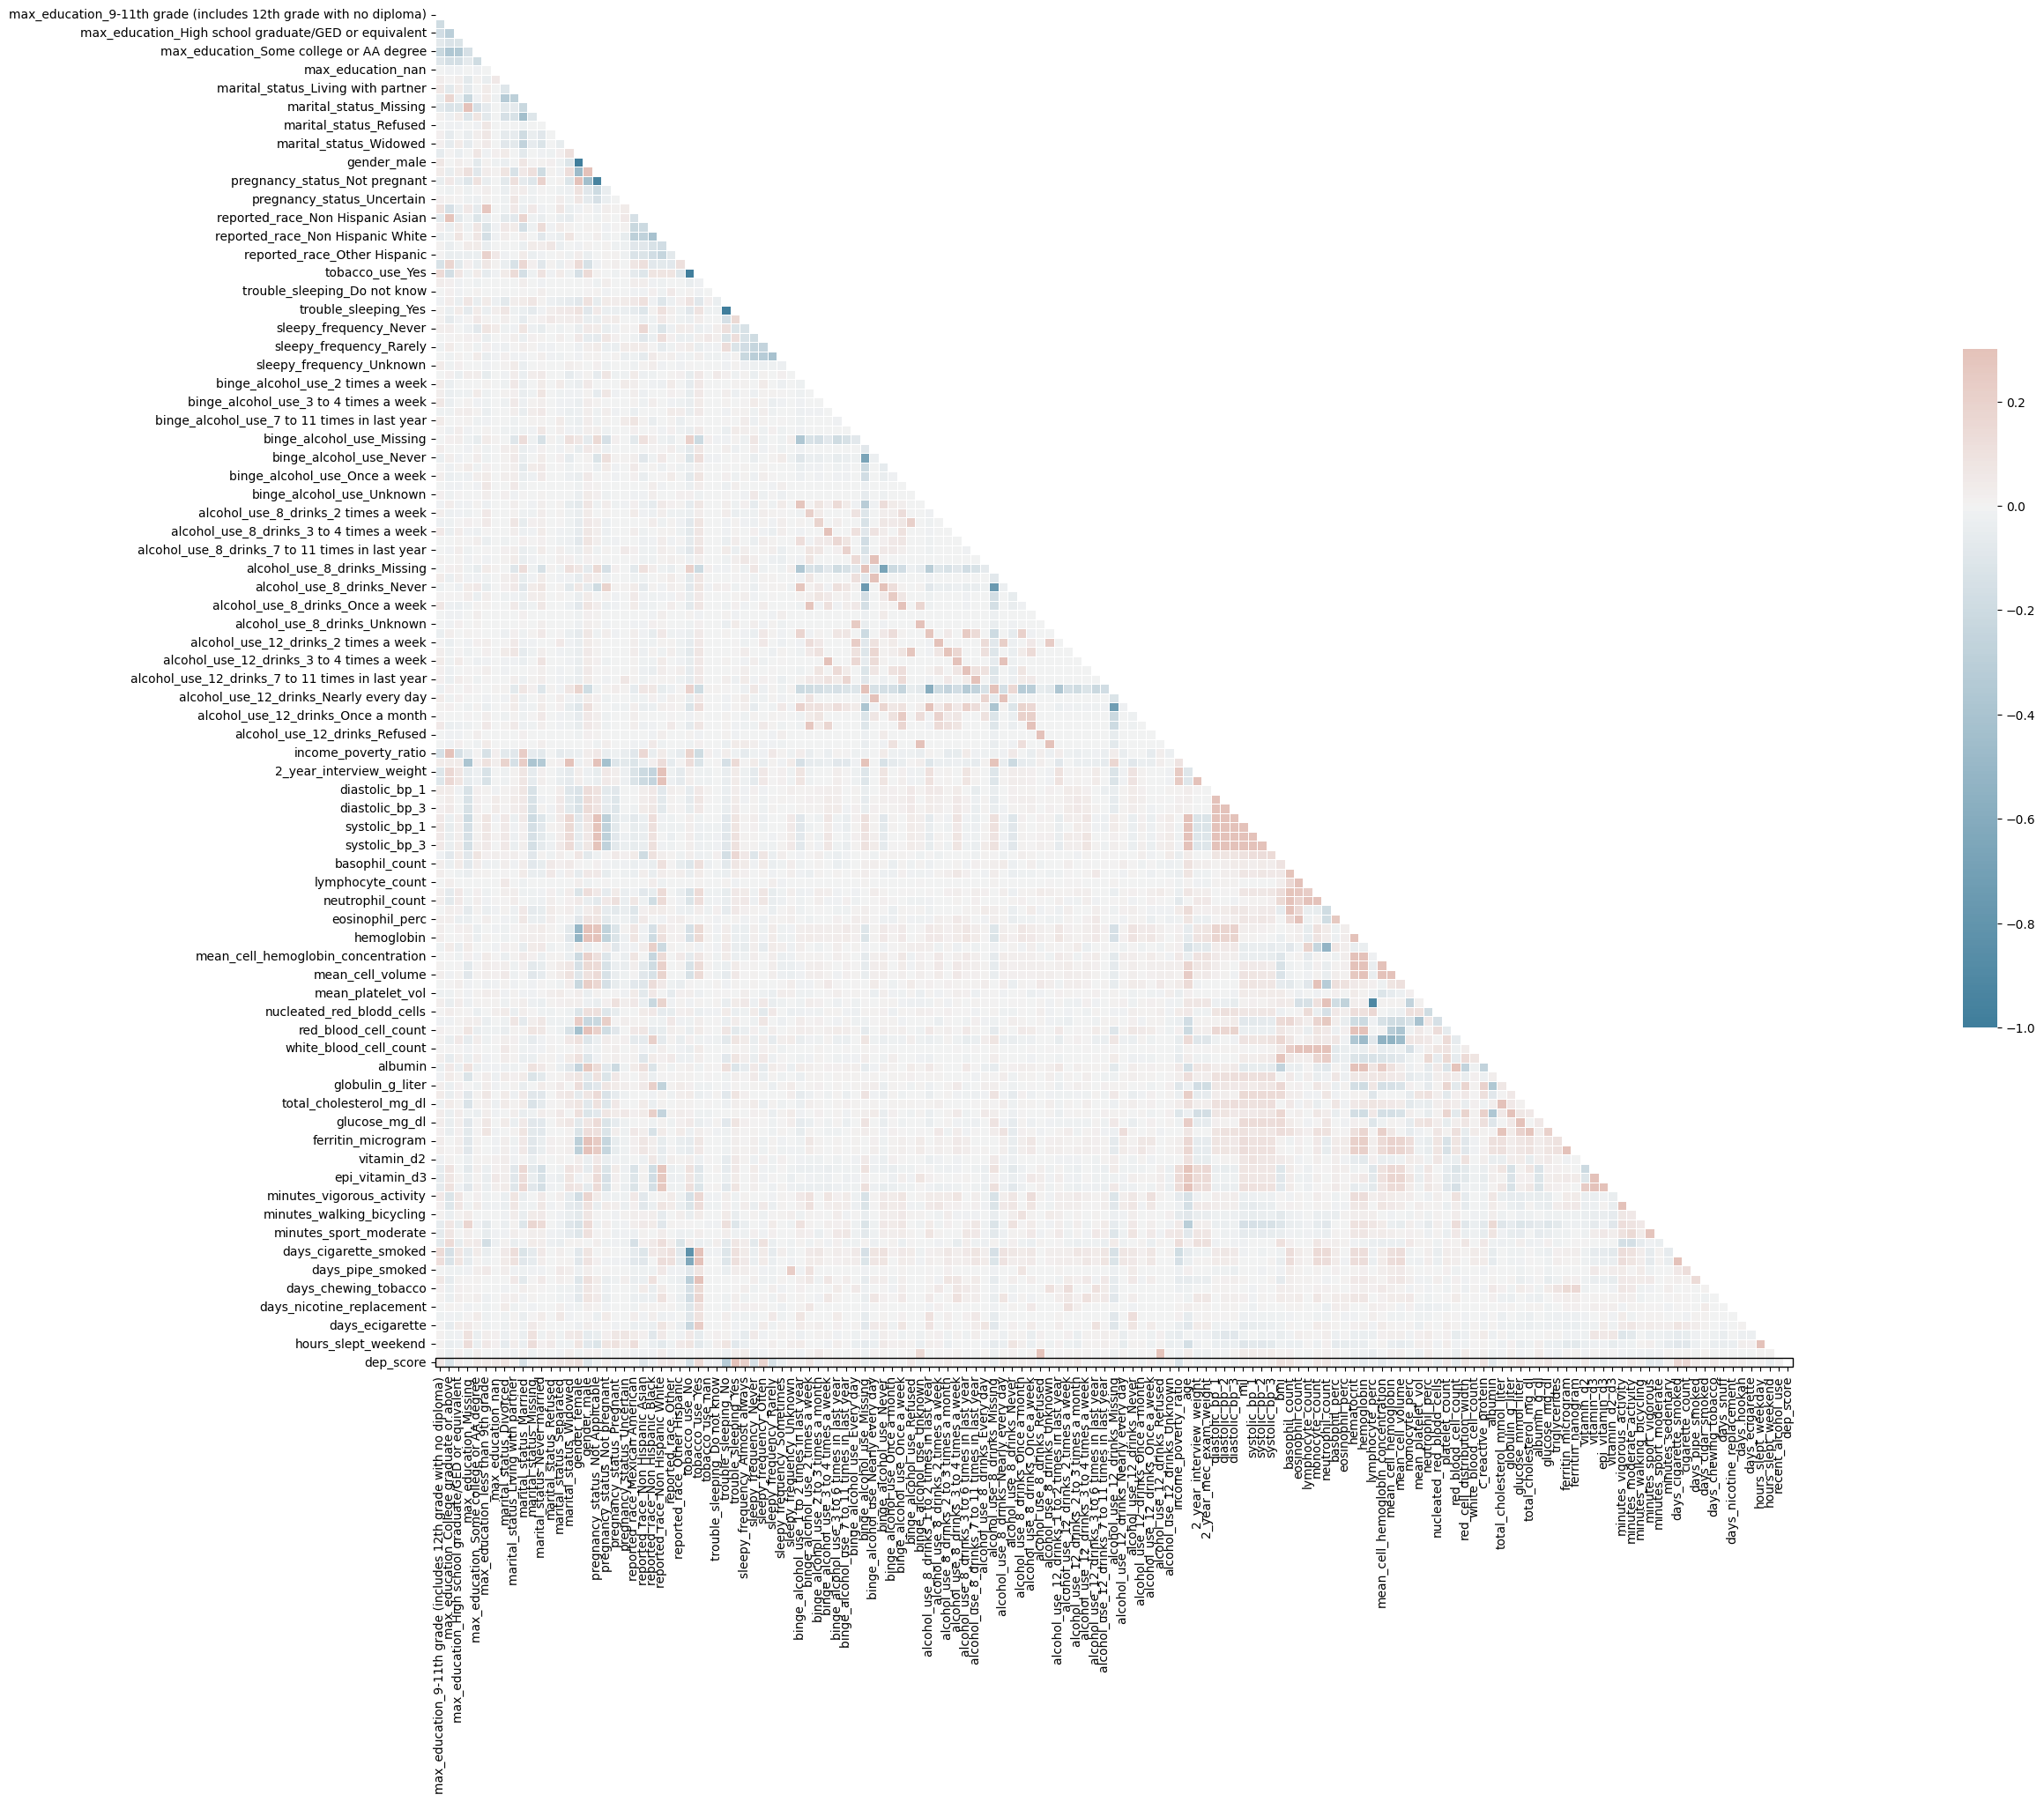

In [19]:

corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(50, 20))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
ax = sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=False)
ax.add_patch(Rectangle((0,len(corr)-1), width=len(corr), height=1, fill=False, edgecolor='black', lw=1, clip_on=False))
plt.show

In [73]:
len(corr)

86